In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.preprocessing import PowerTransformer
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [4]:
CONFIG = {
    'lat_min': 20.85,
    'lat_max': 27.22,
    'lon_min': 85.97,
    'lon_max': 89.84,
    'grid_res': 0.25,
    'lookback': 7,
    'forecast': 1,
    'filters': 64,
    'batch_size': 16,
    'epochs': 10
}


In [5]:
sys.path.append('C:/Users/rishe/Dissertation')

In [6]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows
pd.set_option('display.max_rows', None)

# Set the width to show all content in each cell
pd.set_option('display.width', None)

# Set the max string length to display
pd.set_option('display.max_colwidth', None)

In [7]:
DATA_PATH = f'C:/Users/rishe/Dissertation/data/preprocessed_rain_data.parquet'
EXP_ID = f'exp_10_Conv_Lstm_multi_task'

In [8]:
# Replace with your actual file
df_long = pd.read_parquet(DATA_PATH)

# Ensure correct format
df_long['date'] = pd.to_datetime(df_long['date'])

df_long.head()


,station_id,date,year,month,day,day_of_year,rainfall,lat,lon,district,station_type
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,24.31,88.36,MURSHIDABAD,None
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,24.31,88.36,MURSHIDABAD,None
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,24.31,88.36,MURSHIDABAD,None
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,24.31,88.36,MURSHIDABAD,None
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,24.31,88.36,MURSHIDABAD,None


In [14]:
df_long['rainfall'] = np.where(df_long['rainfall'] >= 2.5, df_long['rainfall'], 0)

In [93]:
df_long['rainfall'].describe(percentiles = [
0.750, 0.755, 0.760, 0.765, 0.770,
0.775, 0.780, 0.785, 0.790, 0.795,
0.800, 0.805, 0.810, 0.815, 0.820,
0.825, 0.830, 0.835, 0.840, 0.845,
0.850, 0.855, 0.860, 0.865, 0.870,
0.875, 0.880, 0.885, 0.890, 0.895,
0.900, 0.905, 0.910, 0.915, 0.920,
0.925, 0.930, 0.935, 0.940, 0.945,
0.950, 0.955, 0.960, 0.965, 0.970,
0.975, 0.980, 0.985, 0.990,
0.995,
0.9995
]
)

count     3.959148e+06
mean      5.422684e+00
std       1.715995e+01
min       0.000000e+00
50%       0.000000e+00
75%       0.000000e+00
75.5%     0.000000e+00
76%       0.000000e+00
76.5%     0.000000e+00
77%       2.500000e+00
77.5%     2.600000e+00
78%       3.000000e+00
78.5%     3.300000e+00
79%       3.600000e+00
79.5%     4.000000e+00
80%       4.300000e+00
80.5%     4.700000e+00
81%       5.100000e+00
81.5%     5.300000e+00
82%       5.800000e+00
82.5%     6.400000e+00
83%       6.800000e+00
83.5%     7.300000e+00
84%       7.600000e+00
84.5%     8.200000e+00
85%       8.900000e+00
85.5%     9.400000e+00
86%       1.020000e+01
86.5%     1.070000e+01
87%       1.140000e+01
87.5%     1.220000e+01
88%       1.270000e+01
88.5%     1.360000e+01
89%       1.450000e+01
89.5%     1.520000e+01
90%       1.640000e+01
90.5%     1.750000e+01
91%       1.860000e+01
91.5%     2.000000e+01
92%       2.110000e+01
92.5%     2.280000e+01
93%       2.420000e+01
93.5%     2.580000e+01
94%       2

In [98]:
df_long[df_long['rainfall']>0]['rainfall'].describe(percentiles = [
.1,.15,.2,.25,.3,.35,.4,.45,.5,
0.750, 0.755, 0.760, 0.765, 0.770,
0.775, 0.780, 0.785, 0.790, 0.795,
0.800, 0.805, 0.810, 0.815, 0.820,
0.825, 0.830, 0.835, 0.840, 0.845,
0.850, 0.855, 0.860, 0.865, 0.870,
0.875, 0.880, 0.885, 0.890, 0.895,
0.900, 0.905, 0.910, 0.915, 0.920,
0.925, 0.930, 0.935, 0.940, 0.945,
0.950, 0.955, 0.960, 0.965, 0.970,
0.975, 0.980, 0.985, 0.990,
0.995,
0.9995
]
)

count     913959.000000
mean          23.490340
std           29.174695
min            2.500000
10%            3.800000
15%            4.600000
20%            5.400000
25%            6.400000
30%            7.600000
35%            8.900000
40%           10.200000
45%           11.800000
50%           13.500000
75%           28.700000
75.5%         29.200000
76%           29.800000
76.5%         30.400000
77%           30.700000
77.5%         31.200000
78%           31.800000
78.5%         32.500000
79%           33.000000
79.5%         33.600000
80%           34.300000
80.5%         35.100000
81%           35.600000
81.5%         36.400000
82%           37.100000
82.5%         38.100000
83%           38.400000
83.5%         39.400000
84%           40.200000
84.5%         41.000000
85%           42.000000
85.5%         43.200000
86%           44.200000
86.5%         45.200000
87%           46.200000
87.5%         47.500000
88%           48.800000
88.5%         50.000000
89%           51

In [9]:
station_counts = df_long.groupby('date')['station_id'].nunique()

print("Total stations:", df_long['station_id'].nunique())
print(station_counts.describe())


Total stations: 293
count    44195.000000
mean        89.583618
std         27.825769
min          9.000000
25%         68.000000
50%         92.000000
75%        113.000000
max        154.000000
Name: station_id, dtype: float64


In [10]:
def create_grid_coords():
    lats = np.arange(CONFIG['lat_min'],
                     CONFIG['lat_max'] + CONFIG['grid_res'],
                     CONFIG['grid_res'])
    
    lons = np.arange(CONFIG['lon_min'],
                     CONFIG['lon_max'] + CONFIG['grid_res'],
                     CONFIG['grid_res'])
    
    lon_mesh, lat_mesh = np.meshgrid(lons, lats)
    return lon_mesh, lat_mesh


In [11]:
def preprocess_and_grid(df, rain_threshold_mm=2.5):

    grid_lon, grid_lat = create_grid_coords()
    height, width = grid_lon.shape

    df = df.sort_values('date')

    # Log transform
    df['rain_scaled'] = np.log1p(df['rainfall'])

    unique_dates = df['date'].unique()

    tensor_frames = []
    kept_dates = []

    TOTAL_STATIONS = df['station_id'].nunique()
    MIN_STATIONS = 60

    print(f"Interpolating {len(unique_dates)} days...")

    for date in tqdm(unique_dates):

        day_data = df[df['date'] == date]
        valid_data = day_data.dropna(subset=['rain_scaled'])

        if len(valid_data) < MIN_STATIONS:
            continue

        points = valid_data[['lon', 'lat']].values
        values = valid_data['rain_scaled'].values

        grid_rain_log = griddata(points, values,
                                 (grid_lon, grid_lat),
                                 method='linear')

        # Valid mask BEFORE nearest fill
        mask_nan = np.isnan(grid_rain_log)
        valid_mask = (~mask_nan).astype(float)

        if mask_nan.any():
            grid_nearest = griddata(points, values,
                                    (grid_lon, grid_lat),
                                    method='nearest')
            grid_rain_log[mask_nan] = grid_nearest[mask_nan]

        grid_rain_log = np.nan_to_num(grid_rain_log, nan=0.0)

        # ------------------------------------------------
        # APPLY IMD THRESHOLD IN MM SPACE
        # ------------------------------------------------
        grid_rain_mm = np.expm1(grid_rain_log)

        # Set rainfall < threshold to 0
        grid_rain_mm[grid_rain_mm < rain_threshold_mm] = 0.0

        # Convert back to log space
        grid_rain_log = np.log1p(grid_rain_mm)
        # ------------------------------------------------

        doy = pd.Timestamp(date).dayofyear
        sin_val = np.sin(2 * np.pi * doy / 365.0)
        cos_val = np.cos(2 * np.pi * doy / 365.0)

        sin_grid = np.full((height, width), sin_val)
        cos_grid = np.full((height, width), cos_val)

        frame = np.stack(
            [grid_rain_log, sin_grid, cos_grid, valid_mask],
            axis=-1
        )

        tensor_frames.append(frame)
        kept_dates.append(date)

    return np.array(tensor_frames), np.array(kept_dates)


In [12]:
def create_sequences_multihead(data, dates, lookback, horizon, rain_threshold=0.1):

    X = []
    Y_reg = []
    Y_bin = []
    target_dates = []

    for i in range(len(data) - lookback - horizon + 1):

        x_seq = data[i:i+lookback]

        # Regression target (log rainfall)
        y_reg = data[i+lookback, :, :, 0]
        y_reg = np.expand_dims(y_reg, axis=-1)

        # Binary occurrence (in mm space)
        rain_mm = np.expm1(y_reg)
        y_bin = (rain_mm > rain_threshold).astype(float)

        X.append(x_seq)
        Y_reg.append(y_reg)
        Y_bin.append(y_bin)
        target_dates.append(dates[i+lookback])

    return (
        np.array(X),
        np.array(Y_reg),
        np.array(Y_bin),
        np.array(target_dates)
    )


In [31]:
def visualize_sample(X, Y, dates, sample_idx=None):

    if sample_idx is None:
        sample_idx = np.random.randint(0, len(X))

    lookback = X.shape[1]

    fig, axes = plt.subplots(1, lookback + 1,
                             figsize=(4*(lookback+1), 4))

    # Shared color scale
    global_max = max(
        np.max(X[sample_idx, :, :, :, 0]),
        np.max(Y[sample_idx, :, :, 0])
    )

    # Handle completely dry case
    if global_max == 0:
        global_max = 1e-6

    # Plot inputs
    for t in range(lookback):
        axes[t].imshow(
            X[sample_idx, t, :, :, 0],
            cmap='Blues',
            vmin=0,
            vmax=global_max,
            origin='lower',
            extent=(CONFIG['lon_min'], CONFIG['lon_max'],
                    CONFIG['lat_min'], CONFIG['lat_max'])
        )
        axes[t].set_title(f"Input t-{lookback-t}")
        axes[t].axis('off')

    # Plot target and store handle for colorbar
    im = axes[-1].imshow(
        Y[sample_idx, :, :, 0],
        cmap='Blues',
        vmin=0,
        vmax=global_max,
        origin='lower',
        extent=(CONFIG['lon_min'], CONFIG['lon_max'],
                CONFIG['lat_min'], CONFIG['lat_max'])
    )

    axes[-1].set_title("Target (Next Day)")
    axes[-1].axis('off')

    plt.suptitle(f"Date: {dates[sample_idx]}")

    fig.colorbar(im, ax=axes.ravel().tolist())

    plt.tight_layout()
    plt.show()


In [23]:
def visualize_month_sample(X, Y, dates, month):

    dates = pd.to_datetime(dates)
    month_mask = dates.month == month

    if np.sum(month_mask) == 0:
        print("No samples for this month.")
        return

    indices = np.where(month_mask)[0]
    sample_idx = np.random.choice(indices)

    visualize_sample(X, Y, dates, sample_idx)


In [15]:
from tensorflow.keras import Input, Model

def build_multitask_convlstm(input_shape, filters=32):

    inputs = Input(shape=input_shape)

    x = layers.ConvLSTM2D(
        filters=filters,
        kernel_size=(3,3),
        padding='same',
        return_sequences=True
    )(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.ConvLSTM2D(
        filters=filters,
        kernel_size=(3,3),
        padding='same',
        return_sequences=False
    )(x)
    x = layers.BatchNormalization()(x)

    # --- Binary Head ---
    binary_out = layers.Conv2D(
        filters=1,
        kernel_size=(1,1),
        activation='sigmoid',
        name='rain_occurrence'
    )(x)

    # --- Regression Head ---
    reg_out = layers.Conv2D(
        filters=1,
        kernel_size=(1,1),
        activation='linear',
        name='rain_amount'
    )(x)

    model = Model(inputs=inputs,
                  outputs=[binary_out, reg_out])

    return model


### Preprocess data and create sequences

In [16]:
tensor_data, unique_dates = preprocess_and_grid(df_long)

Interpolating 44195 days...


100%|██████████| 44195/44195 [08:02<00:00, 91.51it/s] 


In [17]:
X, Y_reg, Y_bin, target_dates = create_sequences_multihead(
    tensor_data,
    unique_dates,
    CONFIG['lookback'],
    CONFIG['forecast']
)

print("X shape:", X.shape)
print("Y_reg shape:", Y_reg.shape)
print("Y_bin shape:", Y_bin.shape)


X shape: (35085, 7, 27, 17, 4)
Y_reg shape: (35085, 27, 17, 1)
Y_bin shape: (35085, 27, 17, 1)


C:\Users\rishe\AppData\Local\Temp\ipykernel_23124\4191617075.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


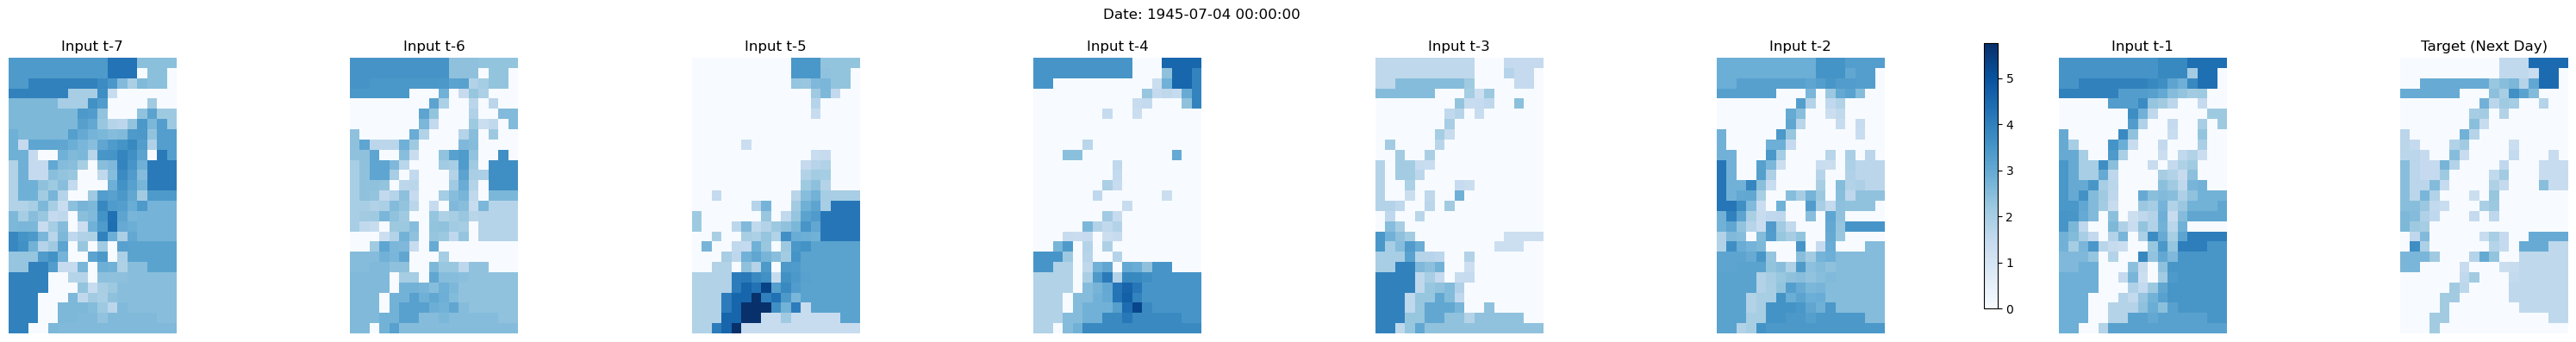

In [62]:
visualize_month_sample(X, Y_reg, target_dates, month=7) 


In [49]:
print("tensor_data shape:", tensor_data.shape)
print("unique_dates length:", len(unique_dates))


tensor_data shape: (35092, 27, 17, 4)
unique_dates length: 35092


In [52]:
sample_idx = 0  # or the one you visualized

print("Target date:", target_dates[sample_idx])

target_frame = Y_reg[sample_idx, :, :, 0]

print("Min:", target_frame.min())
print("Max:", target_frame.max())
print("Mean:", target_frame.mean())


Target date: 1901-01-08 00:00:00
Min: 0.0
Max: 0.0
Mean: 0.0


In [61]:
target_mm = np.expm1(target_frame)
print("Max mm:", target_mm.max())


Max mm: 0.0


In [62]:
print("Any values below threshold but nonzero?")
print(np.any((target_mm < 2.5) & (target_mm > 0)))


Any values below threshold but nonzero?
False


### Test/Train Split

In [64]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]

Y_reg_train, Y_reg_test = Y_reg[:split_idx], Y_reg[split_idx:]
Y_bin_train, Y_bin_test = Y_bin[:split_idx], Y_bin[split_idx:]

dates_train = target_dates[:split_idx]
dates_test  = target_dates[split_idx:]


### Train Model

In [65]:
model = build_multitask_convlstm(
    input_shape=(CONFIG['lookback'],
                 X.shape[2],
                 X.shape[3],
                 4)
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss={
        'rain_occurrence': 'binary_crossentropy',
        'rain_amount': tf.keras.losses.Huber()
    },
    loss_weights={
        'rain_occurrence': 1.0,
        'rain_amount': 1.0
    },
    metrics={
        'rain_occurrence': ['accuracy'],
        'rain_amount': ['mae']
    }
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 7, 27, 17, │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 7, 27, 17, │     41,600 │ input_layer[0][0] │
│ (ConvLSTM2D)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 7, 27, 17, │        128 │ conv_lstm2d[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_1       │ (None, 27, 17,    │     73,856 │ batch_normalizat… │
│ (ConvLSTM2D)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 17,    │        128 │ conv_lstm2d_1[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rain_occurrence     │ (None, 27, 17, 1) │         33 │ batch_normalizat… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rain_amount         │ (None, 27, 17, 1) │         33 │ batch_normalizat… │
│ (Conv2D)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 115,778 (452.26 KB)

 Trainable params: 115,650 (451.76 KB)

 Non-trainable params: 128 (512.00 B)

In [67]:
history = model.fit(
    X_train,
    {
        'rain_occurrence': Y_bin_train,
        'rain_amount': Y_reg_train
    },
    validation_data=(
        X_test,
        {
            'rain_occurrence': Y_bin_test,
            'rain_amount': Y_reg_test
        }
    ),
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size']
)


model.save(
    f'C:/Users/rishe/Dissertation/experiments/saved_models/{EXP_ID}.h5'
)

Epoch 1/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 160s 89ms/step - loss: 0.7488 - rain_amount_loss: 0.3566 - rain_amount_mae: 0.6056 - rain_occurrence_accuracy: 0.8173 - rain_occurrence_loss: 0.3920 - val_loss: 0.6726 - val_rain_amount_loss: 0.3169 - val_rain_amount_mae: 0.5321 - val_rain_occurrence_accuracy: 0.8343 - val_rain_occurrence_loss: 0.3551
Epoch 2/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 166s 95ms/step - loss: 0.7198 - rain_amount_loss: 0.3479 - rain_amount_mae: 0.5924 - rain_occurrence_accuracy: 0.8235 - rain_occurrence_loss: 0.3718 - val_loss: 0.6761 - val_rain_amount_loss: 0.3185 - val_rain_amount_mae: 0.5365 - val_rain_occurrence_accuracy: 0.8329 - val_rain_occurrence_loss: 0.3569
Epoch 3/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 171s 97ms/step - loss: 0.7158 - rain_amount_loss: 0.3462 - rain_amount_mae: 0.5914 - rain_occurrence_accuracy: 0.8246 - rain_occurrence_loss: 0.3695 - val_loss: 0.6688 - val_rain_amount_loss: 0.3160 - val_rain_amount_mae: 0.5297 - val_rain_occurrence_accuracy: 0.8345 

In [30]:
input_shape = (CONFIG['lookback'],
               X.shape[2],
               X.shape[3],
               3)

model = build_convlstm_model(input_shape)

model.compile(optimizer='adam',
              loss=weighted_mse,
              metrics=['mae'])

model.summary()

history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size']
)
model.save(f'C:/Users/rishe/Dissertation/experiments/saved_models/{EXP_ID}.h5')

c:\Users\rishe\anaconda3\envs\torch_cuda\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 7, 27, 17, 64)  │       154,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 27, 17, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 27, 17, 64)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 17, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 27, 17, 1)      │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 450,369 (1.72 MB)

 Trainable params: 450,113 (1.72 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 663s 298ms/step - loss: 1.3004 - mae: 0.7047 - val_loss: 1.2176 - val_mae: 0.6118
Epoch 2/20
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 553s 250ms/step - loss: 1.2122 - mae: 0.6850 - val_loss: 1.2600 - val_mae: 0.6202
Epoch 3/20
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 477s 216ms/step - loss: 1.1932 - mae: 0.6763 - val_loss: 1.1891 - val_mae: 0.7073
Epoch 4/20
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 471s 213ms/step - loss: 1.1876 - mae: 0.6750 - val_loss: 1.1838 - val_mae: 0.6722
Epoch 5/20
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 471s 213ms/step - loss: 1.1821 - mae: 0.6771 - val_loss: 1.1753 - val_mae: 0.6485
Epoch 6/20
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 469s 212ms/step - loss: 1.1723 - mae: 0.6716 - val_loss: 1.1738 - val_mae: 0.6883
Epoch 7/20
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 465s 211ms/step - loss: 1.1650 - mae: 0.6698 - val_loss: 1.1715 - val_mae: 0.6225
Epoch 8/20
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 466s 211ms/step - loss: 1.1604 - mae: 0.6667 - val_loss: 1.1682 - val_mae: 0.6239
Epoch 9/

### Metrics for Multitask convlstm

In [71]:
pred_bin, pred_reg = model.predict(X_test)

pred_mm = np.expm1(pred_reg)
true_mm = np.expm1(Y_reg_test)

final_pred_mm = pred_bin * pred_mm   # recommended physical prediction
dates_test = target_dates[split_idx:]


220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step


In [72]:
pred_flat = final_pred_mm.reshape(-1)
true_flat = true_mm.reshape(-1)

# Remove NaNs if any
mask = ~np.isnan(pred_flat) & ~np.isnan(true_flat)
pred_flat = pred_flat[mask]
true_flat = true_flat[mask]


### overall metrics

In [73]:
rmse = np.sqrt(np.mean((pred_flat - true_flat)**2))
mae  = np.mean(np.abs(pred_flat - true_flat))
bias = np.mean(pred_flat - true_flat)

print("Overall Metrics")
print("RMSE:", rmse)
print("MAE :", mae)
print("Bias:", bias)


Overall Metrics
RMSE: 13.373830232120506
MAE : 3.826124068249627
Bias: -3.2195639623168284


### Monsoon v non monsoon

In [75]:
dates_test = pd.to_datetime(dates_test)

monsoon_mask = np.isin(dates_test.month, [6,7,8,9])

# Expand mask to pixel level
monsoon_mask_pixels = np.repeat(
    monsoon_mask,
    true_mm.shape[1] * true_mm.shape[2]
)

pred_all = final_pred_mm.reshape(-1)
true_all = true_mm.reshape(-1)

monsoon_rmse = np.sqrt(np.mean(
    (pred_all[monsoon_mask_pixels] -
     true_all[monsoon_mask_pixels])**2
))

non_monsoon_rmse = np.sqrt(np.mean(
    (pred_all[~monsoon_mask_pixels] -
     true_all[~monsoon_mask_pixels])**2
))

print("\nMonsoon RMSE:", monsoon_rmse)
print("Non-Monsoon RMSE:", non_monsoon_rmse)



Monsoon RMSE: 20.646717428285537
Non-Monsoon RMSE: 7.536854558510976


### Binary metrics

In [81]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# Binary classification at 2.5mm
true_binary = (true_mm >= 2.5).astype(int).reshape(-1)
pred_binary = (final_pred_mm >= 2.5).astype(int).reshape(-1)

# Confusion matrix
cm = confusion_matrix(true_binary, pred_binary)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nF1 Score:", f1_score(true_binary, pred_binary))

print("\nClassification Report:")
print(classification_report(true_binary, pred_binary, zero_division=0))


Confusion Matrix:
[[2484518   77415]
 [ 465556  193314]]

F1 Score: 0.41590836478954907

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90   2561933
           1       0.71      0.29      0.42    658870

    accuracy                           0.83   3220803
   macro avg       0.78      0.63      0.66   3220803
weighted avg       0.82      0.83      0.80   3220803



In [82]:
def categorize_rain(mm_array):
    cat = np.zeros_like(mm_array)

    cat[(mm_array >= 2.5) & (mm_array < 15)] = 1
    cat[(mm_array >= 15) & (mm_array < 64)] = 2
    cat[(mm_array >= 64) & (mm_array < 115)] = 3
    cat[(mm_array >= 115)] = 4

    return cat


In [83]:
true_cat = categorize_rain(true_mm).reshape(-1)
pred_cat = categorize_rain(final_pred_mm).reshape(-1)


In [84]:
from sklearn.metrics import confusion_matrix

cm_multi = confusion_matrix(true_cat, pred_cat)

print("Multi-class Confusion Matrix:")
print(cm_multi)


Multi-class Confusion Matrix:
[[2484518   73448    3967       0       0]
 [ 307811   80032    8047       0       0]
 [ 142466   70524   14598       0       0]
 [  12686   10596    4112       0       0]
 [   2593    3363    2042       0       0]]


In [85]:
missed_mask = (true_cat > 0) & (pred_cat == 0)

print("Total rainy pixels:", np.sum(true_cat > 0))
print("Missed rainy pixels:", np.sum(missed_mask))
print("Miss rate:", np.mean(missed_mask[true_cat > 0]))


Total rainy pixels: 658870
Missed rainy pixels: 465556
Miss rate: 0.7065976596293654


In [86]:
categories = {
    1: "Light",
    2: "Moderate",
    3: "Heavy",
    4: "Extreme"
}

for k in range(1,5):
    total_k = np.sum(true_cat == k)
    missed_k = np.sum((true_cat == k) & (pred_cat == 0))
    
    if total_k > 0:
        print(f"{categories[k]}:")
        print("  Total:", total_k)
        print("  Missed:", missed_k)
        print("  Miss Rate:", missed_k / total_k)


Light:
  Total: 395890
  Missed: 307811
  Miss Rate: 0.7775164818510192
Moderate:
  Total: 227588
  Missed: 142466
  Miss Rate: 0.6259820377172786
Heavy:
  Total: 27394
  Missed: 12686
  Miss Rate: 0.46309410819887564
Extreme:
  Total: 7998
  Missed: 2593
  Miss Rate: 0.32420605151287823


In [87]:
from sklearn.metrics import classification_report

print(classification_report(true_cat, pred_cat, zero_division=0))


              precision    recall  f1-score   support

         0.0       0.84      0.97      0.90   2561933
         1.0       0.34      0.20      0.25    395890
         2.0       0.45      0.06      0.11    227588
         3.0       0.00      0.00      0.00     27394
         4.0       0.00      0.00      0.00      7998

    accuracy                           0.80   3220803
   macro avg       0.32      0.25      0.25   3220803
weighted avg       0.74      0.80      0.76   3220803



#### monthly rmse

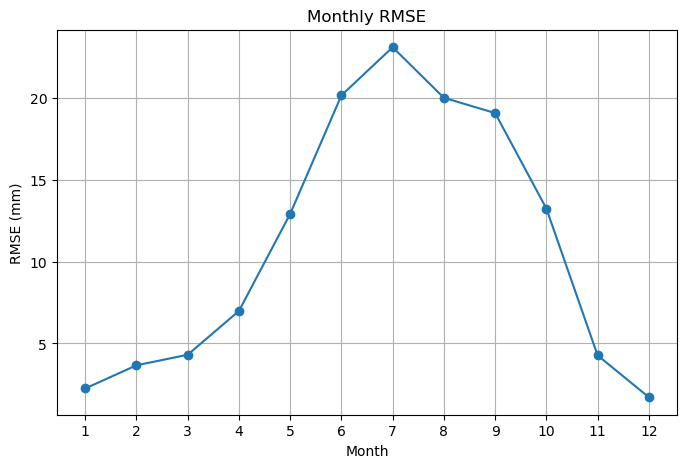

In [88]:
monthly_rmse = []

dates_test = pd.to_datetime(dates_test)

pred_all = final_pred_mm.reshape(-1)
true_all = true_mm.reshape(-1)

H, W = true_mm.shape[1], true_mm.shape[2]

for month in range(1, 13):

    month_mask = dates_test.month == month

    if np.sum(month_mask) == 0:
        monthly_rmse.append(np.nan)
        continue

    month_mask_pixels = np.repeat(
        month_mask,
        H * W
    )

    rmse_m = np.sqrt(np.mean(
        (pred_all[month_mask_pixels] -
         true_all[month_mask_pixels])**2
    ))

    monthly_rmse.append(rmse_m)

plt.figure(figsize=(8,5))
plt.plot(range(1,13), monthly_rmse, marker='o')
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("RMSE (mm)")
plt.title("Monthly RMSE")
plt.grid(True)
plt.show()


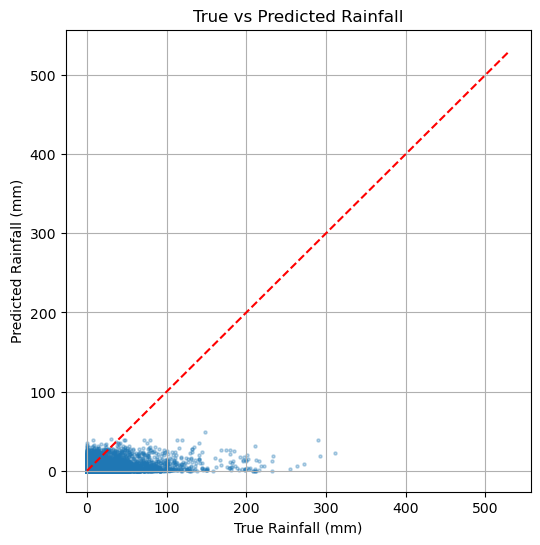

In [89]:
# Sample 50k points for plotting
sample_size = 50000
indices = np.random.choice(len(true_flat),
                           size=min(sample_size, len(true_flat)),
                           replace=False)

plt.figure(figsize=(6,6))
plt.scatter(true_flat[indices],
            pred_flat[indices],
            alpha=0.3,
            s=5)

plt.plot([0, np.max(true_flat)],
         [0, np.max(true_flat)],
         'r--')

plt.xlabel("True Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")
plt.title("True vs Predicted Rainfall")
plt.grid(True)
plt.show()


### Metric Generation

In [46]:
def compute_metrics(y_true, y_pred):

    # Flatten
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    # Remove NaNs and inf
    mask = (
        ~np.isnan(y_true) &
        ~np.isnan(y_pred) &
        ~np.isinf(y_true) &
        ~np.isinf(y_pred)
    )
    print(f'Total y_pred: {len(y_pred)}')
    print(f'Total y_true: {len(y_true)}')
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    print(f'Removed elements: {mask.sum()}')
    print(f'New len y_pred: {len(y_pred)}')

    if len(y_true) == 0:
        return np.nan, np.nan, np.nan

    
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    bias = np.mean(y_pred - y_true)

    return rmse, mae, bias


In [32]:
def compute_metrics(y_true, y_pred):

    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    bias = np.mean(y_pred - y_true)

    return rmse, mae, bias


In [47]:
rmse_all, mae_all, bias_all = compute_metrics(true_mm, pred_mm)

print("Overall Test Metrics")
print("RMSE:", rmse_all)
print("MAE :", mae_all)
print("Bias:", bias_all)


Total y_pred: 4056642
Total y_true: 4056642
Removed elements: 4056587
New len y_pred: 4056587
Overall Test Metrics
RMSE: 13.807205559385478
MAE : 3.8652737313462073
Bias: -2.8130074480003016


### monsoon vs non-monsoon

In [34]:
months_test = pd.to_datetime(dates_test).month
monsoon_months = [6,7,8,9]

monsoon_mask = np.isin(months_test, monsoon_months)
non_monsoon_mask = ~monsoon_mask

rmse_m, mae_m, bias_m = compute_metrics(
    true_mm[monsoon_mask],
    pred_mm[monsoon_mask]
)

rmse_nm, mae_nm, bias_nm = compute_metrics(
    true_mm[non_monsoon_mask],
    pred_mm[non_monsoon_mask]
)

print("\nMonsoon Metrics")
print(rmse_m, mae_m, bias_m)

print("\nNon-Monsoon Metrics")
print(rmse_nm, mae_nm, bias_nm)



Monsoon Metrics
21.357400226160195 8.569545212811581 -6.484292739136209

Non-Monsoon Metrics
nan nan nan


### Monthly error plot

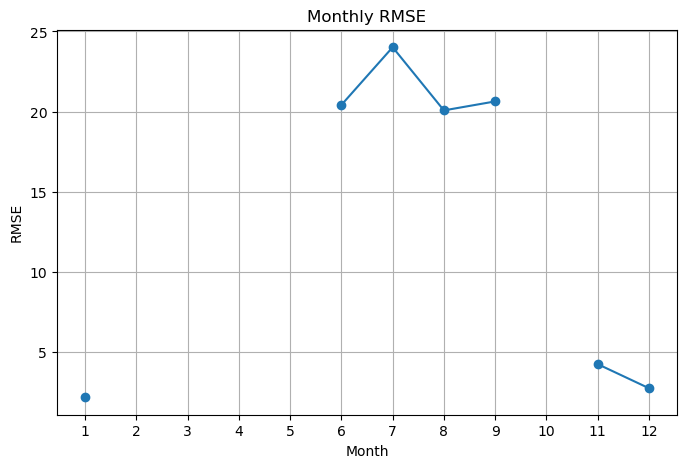

In [35]:
month_list = range(1,13)
month_rmse = []

for m in month_list:
    mask = months_test == m
    if np.sum(mask) > 0:
        r, _, _ = compute_metrics(true_mm[mask], pred_mm[mask])
    else:
        r = np.nan
    month_rmse.append(r)

plt.figure(figsize=(8,5))
plt.plot(month_list, month_rmse, marker='o')
plt.xticks(month_list)
plt.xlabel("Month")
plt.ylabel("RMSE")
plt.title("Monthly RMSE")
plt.grid(True)
plt.show()


### True vs Pred

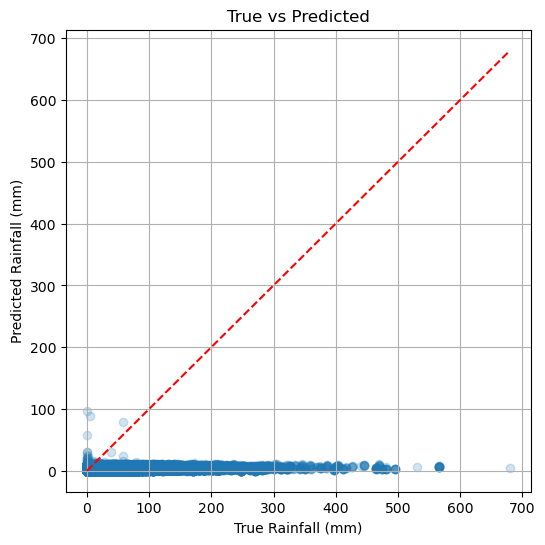

In [36]:
plt.figure(figsize=(6,6))

plt.scatter(true_mm.flatten(),
            pred_mm.flatten(),
            alpha=0.2)

max_val = max(true_mm.max(), pred_mm.max())
plt.plot([0,max_val],[0,max_val],'r--')

plt.xlabel("True Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")
plt.title("True vs Predicted")
plt.grid(True)
plt.show()


### Spatial map comparison

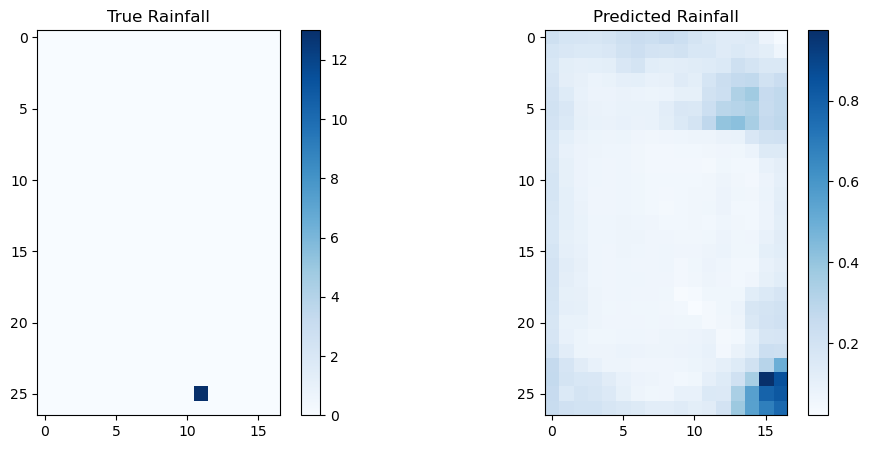

In [37]:
sample_idx = 0

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(true_mm[sample_idx,:,:,0], cmap='Blues')
plt.title("True Rainfall")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(pred_mm[sample_idx,:,:,0], cmap='Blues')
plt.title("Predicted Rainfall")
plt.colorbar()

plt.show()
